# Tipos de dato y sus conversiones

Acompañamiento en código de **la tabla de decisiones** de la clase: la diapositiva que dice, para cada tipo de variable, qué codificación le corresponde y **cuántos floats ocupa** en el vector de entrada.

**Cómo está armado.** Primero vamos **tipo por tipo**. Para cada uno:

1. se carga del CSV la columna y su precio, y se ve qué entró;
2. se ve la conversión, `valor -> floats`;
3. se entrena una **red que recibe esa sola variable** y predice el precio;
4. donde hay una forma incorrecta de codificar, se entrena la misma red con esa forma y se comparan los dos errores.

**Al final se combina todo** en una sola red con el precio completo.

## El dataset

`input-data-types.csv` trae 2000 casas y **dos clases de precio**:

- **`precio`** — el precio completo: todas las variables aportan, más ruido de 18.000. Es el que se usa al final.
- **`precio_solo_…`** — el precio **aislado** de una variable: qué valdría la casa si solo esa variable moviera la aguja. Los coeficientes son los mismos; simplemente se le sacaron los demás términos.

Los precios aislados existen para que cada experimento mida **una cosa sola**. Con el precio completo, los metros cuadrados tapan a todas las demás y ningún efecto chico se distingue.

El dataset es **sintético**: el precio se armó con un aporte por variable —lineal en los metros, saltos desparejos en el estado, un valor propio por barrio y por código postal, una onda anual en el mes— más ruido gaussiano. **18.000 de ruido en el precio completo y 4.000 en los aislados.**

Los precios aislados llevan un ruido de 4.000, así que el **piso de error de cada experimento es de unos $3.200**. Cuando una codificación correcta llega ahí, significa que recuperó todo lo que había para recuperar.

### Declarar el tipo al cargar

Media tabla de decisiones se puede escribir **en el `read_csv`**. Un CSV es todo texto: qué es cada columna lo decide quien la carga, y conviene decirlo una sola vez acá en vez de repetirlo en cada sección.

Tres declaraciones que ya son decisiones de modelado:

- **`codigo_postal` como `category`, no como entero.** Está guardado como número y pandas lo leería como `int64` sin protestar. Declararlo categoría es dejar dicho que la resta entre dos códigos no significa nada.
- **`estado` como categoría *ordenada*.** El orden regular < bueno < muy bueno < excelente no está en los datos: lo pone quien conoce el dominio.
- **`barrio` y `tipo_vivienda` como `category`.** Quedan con su lista de valores y su índice entero, que es justo lo que después necesitan el one-hot y el embedding.

**Y de paso, el `float32`.** Todo lo que la red consume como número —la booleana, los metros, los baños, el ingreso, el mes, el año y los precios— se declara `float32` **acá**. Así ninguna sección tiene que castear: `datos.m2.to_numpy()` ya sale con el tipo que Keras espera, y el código de cada variable habla solo de **la codificación**, no del casteo.

La única que queda afuera a propósito es `codigo_postal`: para tratarla como número hay que forzarla, y ese casteo extra es justamente la señal de la sección 7.

In [1]:
import numpy as np
import pandas as pd
import keras
from keras import layers
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

ORDEN_ESTADO = ["regular", "bueno", "muy bueno", "excelente"]

# Lo que la red consume como numero entra ya en float32; lo que es categoria
# entra como categoria. El casteo se hace una sola vez, aca, y despues ninguna
# seccion tiene que repetirlo.
df = pd.read_csv("input-data-types.csv", dtype={
    "listing_id":    "int64",     # identificador unico: no entra a la red
    "m2":            "float32",   # numerica con magnitud
    "banos":         "float32",   # numerica con magnitud
    "ingreso_zona":  "float32",   # numerica con cola larga
    "tipo_vivienda": "category",  # nominal, cardinalidad baja
    "barrio":        "category",  # nominal, cardinalidad alta
    "codigo_postal": "category",  # codigo con forma de numero: NO es un entero
    "mes_venta":     "float32",   # ciclica
    "anio_alta":     "float32",   # fecha
})
df["estado"] = pd.Categorical(df.estado, categories=ORDEN_ESTADO, ordered=True)

# El CSV trae la booleana como True/False y los precios sin declarar: van a
# float32 igual que el resto. True -> 1.0, False -> 0.0.
df["tiene_cochera"] = df.tiene_cochera.astype("float32")
PRECIOS = [c for c in df.columns if c.startswith("precio")]
df[PRECIOS] = df[PRECIOS].astype("float32")

COLUMNAS = ["listing_id", "tiene_cochera", "m2", "banos", "ingreso_zona",
            "estado", "tipo_vivienda", "barrio", "codigo_postal", "mes_venta", "anio_alta"]
print(f"{len(df)} filas\n")
print(df[COLUMNAS + ["precio"]].head(5).to_string(index=False))


2000 filas

 listing_id  tiene_cochera    m2  banos  ingreso_zona    estado tipo_vivienda    barrio codigo_postal  mes_venta  anio_alta   precio
     271195            0.0 102.0    2.0      113736.0 muy bueno  departamento barrio_27          1017        7.0     1981.0 352432.0
     916831            0.0  35.0    1.0       17201.0 excelente        duplex barrio_15          1022        7.0     1950.0 278612.0
     951972            0.0 162.0    1.0       31383.0 muy bueno          casa barrio_45          1018        8.0     1971.0 482470.0
     199237            0.0  45.0    1.0       59884.0 muy bueno        duplex barrio_58          1012       10.0     1979.0 228560.0
     538038            1.0 110.0    3.0       18842.0 muy bueno          casa barrio_15          1012        7.0     2019.0 413319.0


In [2]:
pd.DataFrame({
    "dtype":     df[COLUMNAS].dtypes.astype(str),
    "distintos": df[COLUMNAS].nunique(),
    "faltantes": df[COLUMNAS].isna().sum(),
    "ejemplos":  [", ".join(map(str, df[c].dropna().unique()[:3])) for c in COLUMNAS],
})

,dtype,distintos,faltantes,ejemplos
listing_id,int64,2000,0,"271195, 916831, 951972"
tiene_cochera,float32,2,0,"0.0, 1.0"
m2,float32,166,0,"102.0, 35.0, 162.0"
banos,float32,3,0,"2.0, 1.0, 3.0"
ingreso_zona,float32,1981,0,"113736.0, 17201.0, 31383.0"
estado,category,4,0,"muy bueno, excelente, bueno"
tipo_vivienda,category,4,0,"departamento, duplex, casa"
barrio,category,60,0,"barrio_27, barrio_15, barrio_45"
codigo_postal,category,40,0,"1017, 1022, 1018"
mes_venta,float32,12,0,"7.0, 8.0, 10.0"


### Un render único para las comparativas

Casi todas las secciones que siguen hacen lo mismo: entrenan **la misma red dos veces**, una con la codificación incorrecta y otra con la correcta, y comparan el error. Para no repetir el gráfico en cada sección, el render sale una sola vez acá.

Cada comparativa muestra dos cosas:

- **cómo baja el error época a época** — ahí se ve la velocidad de convergencia;
- **dónde termina cada una**, contra el **baseline**: el error de predecir siempre el precio promedio. Una codificación que no llega a bajar del baseline no le está aportando nada a la red.

La forma incorrecta va siempre **primero y en rojo**.


In [3]:
COLOR_MAL, COLOR_BIEN, COLOR_GUIA = "#DA1B2E", "#3B3535", "#B9B3B3"

def comparar(titulo, corridas, base=None, clave="mae", piso=None):
    """Render unico de todas las comparativas del notebook.

    corridas : lista de (etiqueta, history, mae_final). La forma INCORRECTA va
               primero, y queda en rojo.
    base     : MAE del baseline, en miles. Se dibuja como linea punteada.
    clave    : "mae" para la curva de train, "val_mae" para la de validacion.
    piso     : ruido del dataset, en dolares, cuando se conoce.
    """
    dolares = FuncFormatter(lambda v, _: f"${v:,.0f}")
    fig, (ax_curva, ax_final) = plt.subplots(
        1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
    colores = [COLOR_MAL, COLOR_BIEN]

    vistos = []
    for (etiqueta, h, _), color in zip(corridas, colores):
        curva = np.array(h.history[clave]) * 1000
        vistos.append(curva)
        ax_curva.plot(np.arange(1, len(curva) + 1), curva,
                      "o-" if len(curva) <= 20 else "-", color=color, label=etiqueta)
    if base is not None:
        ax_curva.axhline(base * 1000, ls="--", lw=1, color=COLOR_GUIA, label="baseline")
    if piso is not None:
        ax_curva.axhline(piso, ls=":", lw=1.2, color=COLOR_GUIA, label="piso del dataset")
    # Casi todo el descenso pasa en las primeras epocas: en escala lineal el resto
    # de la curva queda aplastado contra el piso y las dos parecen iguales.
    alto, bajo = max(c.max() for c in vistos), min(c[c > 0].min() for c in vistos)
    if alto / bajo > 6:
        ax_curva.set_yscale("log")
        ax_curva.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
        ax_curva.yaxis.set_minor_formatter(NullFormatter())
    ax_curva.set_xlabel("época")
    ax_curva.set_ylabel("MAE en dólares")
    ax_curva.set_title("cómo baja el error")
    ax_curva.yaxis.set_major_formatter(dolares)
    ax_curva.legend(); ax_curva.grid(alpha=.3, which="both")

    etiquetas = [e for e, _, _ in corridas]
    finales   = [m * 1000 for _, _, m in corridas]
    barras = ax_final.bar(etiquetas, finales, color=colores[:len(corridas)], width=.55)
    ax_final.bar_label(barras, labels=[f"${v:,.0f}" for v in finales], padding=3)
    if base is not None:
        ax_final.axhline(base * 1000, ls="--", lw=1, color=COLOR_GUIA)
        ax_final.text(1.02, base * 1000, "baseline", va="center", fontsize=8,
                      color=COLOR_GUIA, transform=ax_final.get_yaxis_transform())
    tope = max(finales + ([base * 1000] if base is not None else []))
    ax_final.set_ylim(0, tope * 1.28)
    ax_final.set_ylabel("MAE en dólares")
    ax_final.set_title("dónde termina")
    ax_final.yaxis.set_major_formatter(dolares)
    ax_final.grid(alpha=.3, axis="y"); ax_final.set_axisbelow(True)

    fig.suptitle(titulo)
    fig.tight_layout()
    plt.show()


## 1 · Booleana → 0 o 1 · **1 float**

Ya está en la escala que la red espera. No se normaliza.

In [4]:
datos = df[["tiene_cochera", "precio_solo_cochera"]]
print(datos.head(8).to_string(index=False))

# .to_numpy() ya no convierte nada: el dtype quedo fijado en la carga. Lo unico
# que hace es cambiar el envase, de Series de pandas a array de numpy, que es lo
# que piden .reshape() y Keras.
X = datos.tiene_cochera.to_numpy().reshape(-1, 1)
y = datos.precio_solo_cochera.to_numpy() / 1000     # en miles

print("\nvalor     ->  float")
for v in [True, False]:
    print(f"  {str(v):<7} ->  [{float(v):+.2f}]")


 tiene_cochera  precio_solo_cochera
           0.0              60254.0
           0.0              58023.0
           0.0              61917.0
           0.0              65380.0
           1.0              77061.0
           1.0              85646.0
           0.0              62273.0
           0.0              57099.0

valor     ->  float
  True    ->  [+1.00]
  False   ->  [+0.00]


In [5]:
# Semilla fija. Los pesos iniciales, el orden de los batches y cualquier otro
# sorteo de Keras salen siempre iguales, asi el MAE que imprime esta celda es el
# mismo en cada corrida. Sin esto, dos numeros distintos no dirian si cambio la
# codificacion o si simplemente toco otro azar. Se repite antes de CADA red del
# notebook, para que las que se comparan arranquen del mismo punto.
keras.utils.set_random_seed(42)
red = keras.Sequential([
    keras.Input(shape=(1,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
red.fit(X, y, epochs=300, batch_size=32, verbose=0)

print(f"cochera como 0/1   MAE ${red.evaluate(X, y, verbose=0)[1]*1000:,.0f}"
      f"   (baseline ${np.abs(y - y.mean()).mean()*1000:,.0f})")
print("\nla red separa los dos grupos: el error cae muy por debajo del baseline")

cochera como 0/1   MAE $3,188   (baseline $7,401)

la red separa los dos grupos: el error cae muy por debajo del baseline


## 2 · Numérica con magnitud → z-score · **1 float**

Los metros cuadrados tienen magnitud, y la resta entre dos valores significa algo. Se estandariza a media 0 y desvío 1.

**Por qué importa.** El gradiente de un peso es proporcional al valor de su entrada, y el learning rate es uno solo para toda la red. Si una variable va en cientos y otra en unidades, sus gradientes viven en escalas distintas y un solo paso no le sirve a las dos.

Por eso este experimento usa **dos** variables que compiten: los metros cuadrados (decenas y cientos) y la cantidad de baños (1 a 3).

In [ ]:
datos = df[["m2", "banos", "precio_solo_m2_banos"]]
print(datos.head(8).to_string(index=False))

y = datos.precio_solo_m2_banos.to_numpy() / 1000
m2, banos = datos.m2.to_numpy(), datos.banos.to_numpy()

mu, sd = m2.mean(), m2.std()
print(f"\nm²:  μ = {mu:.1f}   σ = {sd:.1f} baños:  μ = {banos.mean():.2f}   σ = {banos.std():.2f}")
print("\nvalor          ->  float")
for v in [35, 62, 95, 130, 260]:
    print(f"  {v:<12} ->  [{(v - mu) / sd:+.2f}]")

   m2  banos  precio_solo_m2_banos
102.0    2.0              269627.0
 35.0    1.0              131207.0
162.0    1.0              358569.0
 45.0    1.0              151687.0
110.0    3.0              285589.0
109.0    2.0              278133.0
105.0    2.0              271727.0
 78.0    2.0              217031.0

m²:  μ = 96.5   σ = 35.0        baños:  μ = 2.01   σ = 0.81

valor          ->  float
  35           ->  [-1.76]
  62           ->  [-0.99]
  95           ->  [-0.04]
  130          ->  [+0.96]
  260          ->  [+4.68]


In [7]:
crudo  = np.stack([m2, banos], axis=1)
zscore = np.stack([(m2 - mu) / sd,
                   (banos - banos.mean()) / banos.std()], axis=1)
base = np.abs(y - y.mean()).mean()

print("sin normalizar, las dos columnas entran así:")
print(crudo[:4])
print("\ncon z-score:")
print(np.round(zscore[:4], 2))

sin normalizar, las dos columnas entran así:
[[102.   2.]
 [ 35.   1.]
 [162.   1.]
 [ 45.   1.]]

con z-score:
[[ 0.16 -0.01]
 [-1.76 -1.25]
 [ 1.87 -1.25]
 [-1.47 -1.25]]


#### Caso 1: sin normalizar

SGD usa **un solo paso para toda la red**, así que las dos variables comparten learning rate.

Arrancamos con **10 épocas**, que son pocas a propósito: alcanzan para ver a qué velocidad baja cada una.

In [8]:
keras.utils.set_random_seed(42)
sgd_crudo = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
sgd_crudo.compile(optimizer=keras.optimizers.SGD(0.001), loss="mse", metrics=["mae"])
h_crudo = sgd_crudo.fit(crudo, y, epochs=10, batch_size=32, verbose=0)
mae_crudo = sgd_crudo.evaluate(crudo, y, verbose=0)[1]

print(f"SGD, sin normalizar, 10 épocas   MAE ${mae_crudo*1000:,.0f}"
      f"   (baseline ${base*1000:,.0f})")
print("\ntodavía está por encima del baseline: viene bajando desde muy arriba")
print("y en diez épocas ni siquiera llegó a la altura del precio promedio")


SGD, sin normalizar, 10 épocas   MAE $154,275   (baseline $50,984)

todavía está por encima del baseline: viene bajando desde muy arriba
y en diez épocas ni siquiera llegó a la altura del precio promedio


#### Caso 2: con z-score

Misma red, mismo optimizador, mismas épocas. Lo único que cambia es la escala de las dos columnas.

In [9]:
# Misma semilla que la celda anterior: esta red arranca con exactamente los
# mismos pesos que la cruda, asi lo unico que cambia entre las dos es la escala
# de la entrada.
keras.utils.set_random_seed(42)
sgd_z = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
sgd_z.compile(optimizer=keras.optimizers.SGD(0.001), loss="mse", metrics=["mae"])
h_z = sgd_z.fit(zscore, y, epochs=10, batch_size=32, verbose=0)
mae_z = sgd_z.evaluate(zscore, y, verbose=0)[1]

print(f"SGD, con z-score, 10 épocas      MAE ${mae_z*1000:,.0f}"
      f"   (baseline ${base*1000:,.0f})")
print("\nen diez épocas ya tocó el piso del experimento")


SGD, con z-score, 10 épocas      MAE $3,220   (baseline $50,984)

en diez épocas ya tocó el piso del experimento


#### Los dos, uno al lado del otro

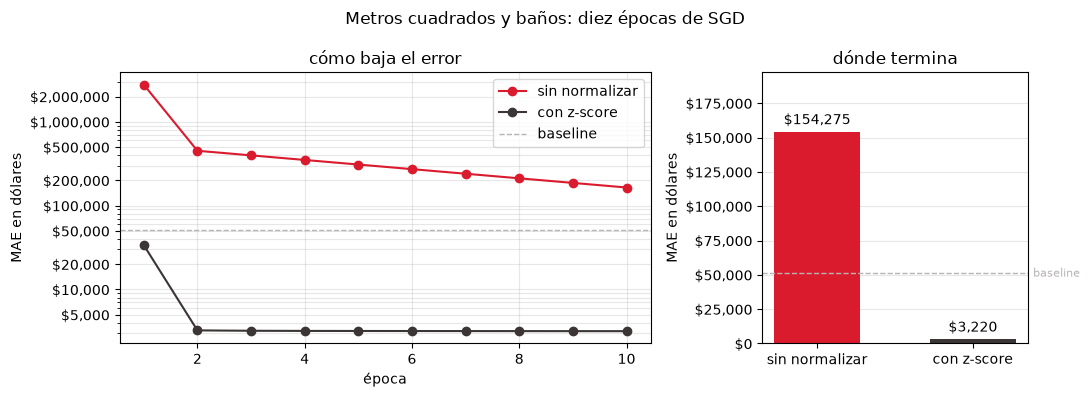

la curva con z-score cae al piso en las primeras épocas.
la cruda arranca muy arriba y baja tan despacio que a las diez todavía
no alcanzó ni el baseline. Esa es la convergencia lenta.


In [10]:
comparar("Metros cuadrados y baños: diez épocas de SGD", [
    ("sin normalizar", h_crudo, mae_crudo),
    ("con z-score",    h_z,     mae_z),
], base=base)

print("la curva con z-score cae al piso en las primeras épocas.")
print("la cruda arranca muy arriba y baja tan despacio que a las diez todavía")
print("no alcanzó ni el baseline. Esa es la convergencia lenta.")


#### ¿Y si le damos más tiempo?

La pregunta obvia es si la versión sin normalizar simplemente necesita más épocas. Con 300, treinta veces más:

In [11]:
keras.utils.set_random_seed(42)
largo_crudo = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
largo_crudo.compile(optimizer=keras.optimizers.SGD(0.001), loss="mse", metrics=["mae"])
largo_crudo.fit(crudo, y, epochs=300, batch_size=32, verbose=0)

keras.utils.set_random_seed(42)
largo_z = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
largo_z.compile(optimizer=keras.optimizers.SGD(0.001), loss="mse", metrics=["mae"])
largo_z.fit(zscore, y, epochs=300, batch_size=32, verbose=0)

print(f"SGD, sin normalizar, 300 épocas   MAE ${largo_crudo.evaluate(crudo, y, verbose=0)[1]*1000:,.0f}"
      f"   (baseline ${base*1000:,.0f})")
print(f"SGD, con z-score, 300 épocas      MAE ${largo_z.evaluate(zscore, y, verbose=0)[1]*1000:,.0f}"
      f"   (baseline ${base*1000:,.0f})")
print("\nno era cuestión de tiempo: sin normalizar sigue clavada en el baseline.")

SGD, sin normalizar, 300 épocas   MAE $50,983   (baseline $50,984)
SGD, con z-score, 300 épocas      MAE $3,191   (baseline $50,984)

no era cuestión de tiempo: sin normalizar sigue clavada en el baseline.


In [12]:
# El mismo experimento con Adam, que adapta el paso a cada parametro.
keras.utils.set_random_seed(42)
adam_crudo = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
adam_crudo.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
adam_crudo.fit(crudo, y, epochs=300, batch_size=32, verbose=0)

keras.utils.set_random_seed(42)
adam_z = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
adam_z.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
adam_z.fit(zscore, y, epochs=300, batch_size=32, verbose=0)

print(f"Adam, sin normalizar   MAE ${adam_crudo.evaluate(crudo, y, verbose=0)[1]*1000:,.0f}")
print(f"Adam, con z-score      MAE ${adam_z.evaluate(zscore, y, verbose=0)[1]*1000:,.0f}")
print("\nAdam absorbe casi toda la diferencia, porque adapta el paso a cada parámetro.")
print("Eso no es licencia para no normalizar: mitiga el problema de escala, pero no")
print("arregla la saturación de las activaciones ni una inicialización rota.")

Adam, sin normalizar   MAE $3,238
Adam, con z-score      MAE $3,098

Adam absorbe casi toda la diferencia, porque adapta el paso a cada parámetro.
Eso no es licencia para no normalizar: mitiga el problema de escala, pero no
arregla la saturación de las activaciones ni una inicialización rota.


## 3 · Numérica con cola larga → log y después z-score · **1 float**

El ingreso de la zona tiene cola larga: casi todos los valores abajo y unos pocos muy arriba. El z-score solo no alcanza, porque los extremos siguen dominando el rango. Primero `log(1+x)`, que comprime la cola, y recién después el z-score.

In [13]:
datos = df[["ingreso_zona", "precio_solo_ingreso"]]
print(datos.head(8).to_string(index=False))

ingreso = datos.ingreso_zona.to_numpy()
y = datos.precio_solo_ingreso.to_numpy() / 1000

mu_i, sd_i = ingreso.mean(), ingreso.std()
li = np.log1p(ingreso)
mu_l, sd_l = li.mean(), li.std()

print(f"\ningreso:  mínimo ${ingreso.min():,.0f}   mediana ${np.median(ingreso):,.0f}   máximo ${ingreso.max():,.0f}")
print("\nvalor            solo z-score      log y después z-score")
for v in [9_000, 25_000, 40_000, 120_000, 900_000]:
    print(f"  {v:<12,}   [{(v - mu_i)/sd_i:+6.2f}]           [{(np.log1p(v) - mu_l)/sd_l:+6.2f}]")
print("\ncon z-score solo el extremo se dispara y aplasta al resto")

 ingreso_zona  precio_solo_ingreso
     113736.0             156050.0
      17201.0             143861.0
      31383.0             144886.0
      59884.0             149646.0
      18842.0             142391.0
     129803.0             155391.0
      38584.0             142361.0
      52506.0             154127.0

ingreso:  mínimo $2,157   mediana $35,959   máximo $909,508

valor            solo z-score      log y después z-score
  9,000          [ -0.80]           [ -1.69]
  25,000         [ -0.49]           [ -0.45]
  40,000         [ -0.20]           [ +0.13]
  120,000        [ +1.35]           [ +1.47]
  900,000        [+16.45]           [ +3.93]

con z-score solo el extremo se dispara y aplasta al resto


ingreso con z-score solo    MAE $4,182   (baseline $5,991)
ingreso con log + z-score   MAE $3,209   (baseline $5,991)


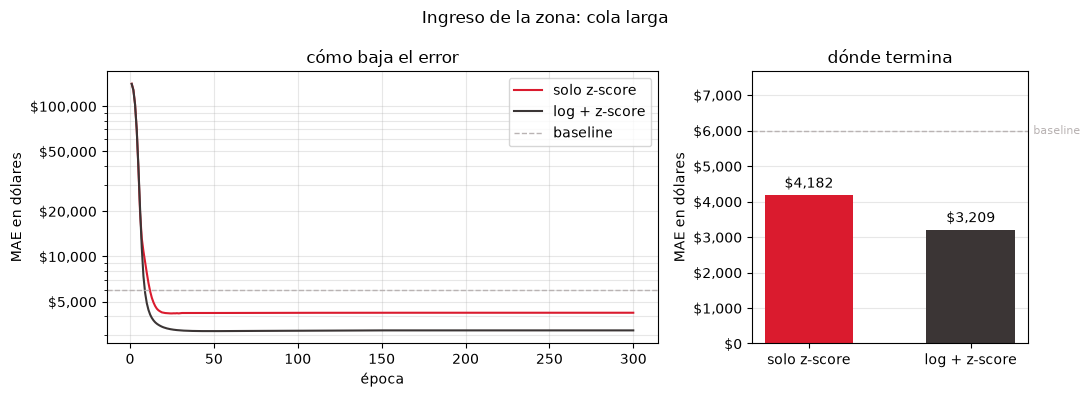

In [14]:
X_mal = ((ingreso - mu_i) / sd_i).reshape(-1, 1)
keras.utils.set_random_seed(42)
red_mal = keras.Sequential([
    keras.Input(shape=(1,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_mal.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_mal = red_mal.fit(X_mal, y, epochs=300, batch_size=32, verbose=0)

X_bien = ((li - mu_l) / sd_l).reshape(-1, 1)
keras.utils.set_random_seed(42)
red_bien = keras.Sequential([
    keras.Input(shape=(1,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_bien.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_bien = red_bien.fit(X_bien, y, epochs=300, batch_size=32, verbose=0)

base = np.abs(y - y.mean()).mean()
mae_mal  = red_mal.evaluate(X_mal, y, verbose=0)[1]
mae_bien = red_bien.evaluate(X_bien, y, verbose=0)[1]
print(f"ingreso con z-score solo    MAE ${mae_mal*1000:,.0f}   (baseline ${base*1000:,.0f})")
print(f"ingreso con log + z-score   MAE ${mae_bien*1000:,.0f}   (baseline ${base*1000:,.0f})")

comparar("Ingreso de la zona: cola larga", [
    ("solo z-score",  h_mal,  mae_mal),
    ("log + z-score", h_bien, mae_bien),
], base=base)


## 4 · Ordinal → float más one-hot · **1 + k floats**

El estado tiene orden (regular < bueno < muy bueno < excelente) pero **las distancias no son iguales**: el salto de muy bueno a excelente no vale lo mismo que el de regular a bueno.

El float conserva el orden; el one-hot le deja a la red aprender el salto de cada nivel por separado. Van los dos, concatenados.

In [15]:
datos = df[["estado", "precio_solo_estado"]]
print(datos.head(8).to_string(index=False))
print("\nprecio promedio por nivel:")
print(datos.groupby("estado", observed=True).precio_solo_estado.mean().to_string())
print("\n-> los saltos entre niveles no son iguales")

   estado  precio_solo_estado
muy bueno            100904.0
excelente            181435.0
muy bueno             98738.0
muy bueno            112251.0
muy bueno             98138.0
excelente            177144.0
    bueno             73013.0
    bueno             79147.0

precio promedio por nivel:
estado
regular       60387.238281
bueno         75078.945312
muy bueno    105246.656250
excelente    180146.734375

-> los saltos entre niveles no son iguales


In [16]:
# El orden ya vino declarado al cargar, asi que `.cat.codes` lo da hecho.
print("nivel  ->  codigo")
for v, c in zip(df.estado.cat.categories, range(len(ORDEN_ESTADO))):
    print(f"  {v:<12} ->  {c}")

def ordinal(s):
    niv = s.cat.codes.to_numpy(dtype="float32")
    k = len(s.cat.categories)
    escala = (niv / (k - 1)).reshape(-1, 1)                       # 0 .. 1, conserva el orden
    return np.hstack([escala, np.eye(k, dtype="float32")[niv.astype(int)]])

print("\nvalor             ->  floats                          (1 de orden + 4 de one-hot)")
demo = pd.Series(pd.Categorical(ORDEN_ESTADO, categories=ORDEN_ESTADO, ordered=True))
for v, f in zip(ORDEN_ESTADO, ordinal(demo)):
    print(f"  {v:<15} ->  {np.round(f, 2)}")

nivel  ->  codigo
  regular      ->  0
  bueno        ->  1
  muy bueno    ->  2
  excelente    ->  3

valor             ->  floats                          (1 de orden + 4 de one-hot)
  regular         ->  [0. 1. 0. 0. 0.]
  bueno           ->  [0.33 0.   1.   0.   0.  ]
  muy bueno       ->  [0.67 0.   0.   1.   0.  ]
  excelente       ->  [1. 0. 0. 0. 1.]


estado como float de orden    MAE $11,950   (baseline $29,193)
estado como float + one-hot   MAE $3,229   (baseline $29,193)

el float solo tiene que aproximar saltos desparejos; el one-hot los aprende exactos


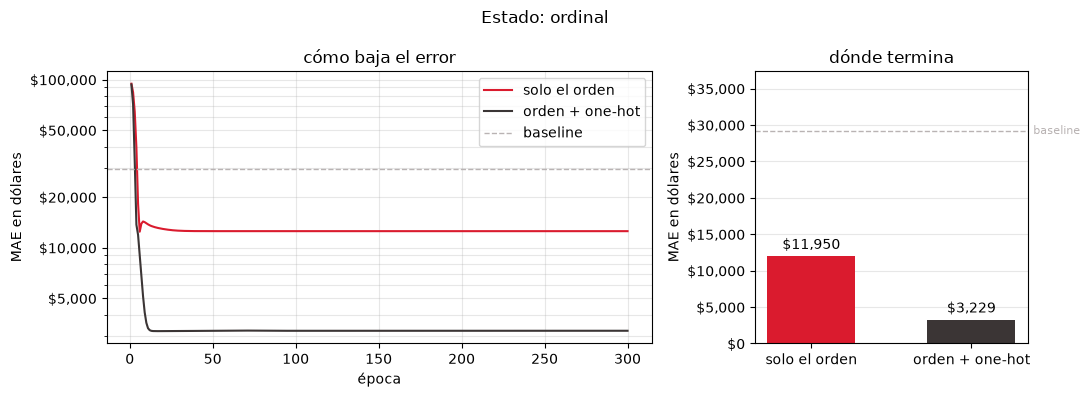

In [17]:
y = datos.precio_solo_estado.to_numpy() / 1000
niv = datos.estado.cat.codes.to_numpy(dtype="float32")

X_mal = (niv / 3).reshape(-1, 1)
keras.utils.set_random_seed(42)
red_mal = keras.Sequential([
    keras.Input(shape=(1,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_mal.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_mal = red_mal.fit(X_mal, y, epochs=300, batch_size=32, verbose=0)

X_bien = ordinal(datos.estado)
keras.utils.set_random_seed(42)
red_bien = keras.Sequential([
    keras.Input(shape=(5,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_bien.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_bien = red_bien.fit(X_bien, y, epochs=300, batch_size=32, verbose=0)

base = np.abs(y - y.mean()).mean()
mae_mal  = red_mal.evaluate(X_mal, y, verbose=0)[1]
mae_bien = red_bien.evaluate(X_bien, y, verbose=0)[1]
print(f"estado como float de orden    MAE ${mae_mal*1000:,.0f}   (baseline ${base*1000:,.0f})")
print(f"estado como float + one-hot   MAE ${mae_bien*1000:,.0f}   (baseline ${base*1000:,.0f})")
print("\nel float solo tiene que aproximar saltos desparejos; el one-hot los aprende exactos")

comparar("Estado: ordinal", [
    ("solo el orden",  h_mal,  mae_mal),
    ("orden + one-hot", h_bien, mae_bien),
], base=base)


## 5 · Nominal de cardinalidad baja → one-hot · **k floats**

El tipo de vivienda tiene pocos valores y ningún orden. One-hot: una posición por categoría, un peso propio para cada una.

**La forma incorrecta** es numerarlas. Eso inventa un orden y una distancia que no existen.

In [18]:
datos = df[["tipo_vivienda", "precio_solo_tipo"]]
print(datos.head(8).to_string(index=False))
print("\nprecio promedio por tipo:")
print(datos.groupby("tipo_vivienda", observed=True).precio_solo_tipo.mean()
      .sort_values(ascending=False).to_string())

tipo_vivienda  precio_solo_tipo
 departamento           61126.0
       duplex           75615.0
         casa           75284.0
       duplex           78230.0
         casa           74550.0
         casa           86611.0
           PH           46840.0
       duplex           66525.0

precio promedio por tipo:
tipo_vivienda
casa            79873.875000
duplex          70033.648438
departamento    60270.996094
PH              51873.042969


In [19]:
TIPOS = list(df.tipo_vivienda.cat.categories)      # ya vino con la carga

def onehot(s, categorias):
    ind = {c: i for i, c in enumerate(categorias)}
    m = np.zeros((len(s), len(categorias)), dtype="float32")
    for f, v in enumerate(s):
        if v in ind:
            m[f, ind[v]] = 1.0
    return m

ej = pd.Series(TIPOS + ["castillo"])          # la última no está en el diccionario
print("valor             ->  floats")
for v, f in zip(ej, onehot(ej, TIPOS)):
    print(f"  {v:<15} ->  {np.round(f, 2)}")
print("\nla categoría no vista queda en todo cero")

valor             ->  floats
  PH              ->  [1. 0. 0. 0.]
  casa            ->  [0. 1. 0. 0.]
  departamento    ->  [0. 0. 1. 0.]
  duplex          ->  [0. 0. 0. 1.]
  castillo        ->  [0. 0. 0. 0.]

la categoría no vista queda en todo cero


tipo numerado 0,1,2,3   MAE $8,811   (baseline $9,680)
tipo con one-hot        MAE $3,173   (baseline $9,680)

numerarlas obliga a la red a inventar un orden entre categorías que no lo tienen


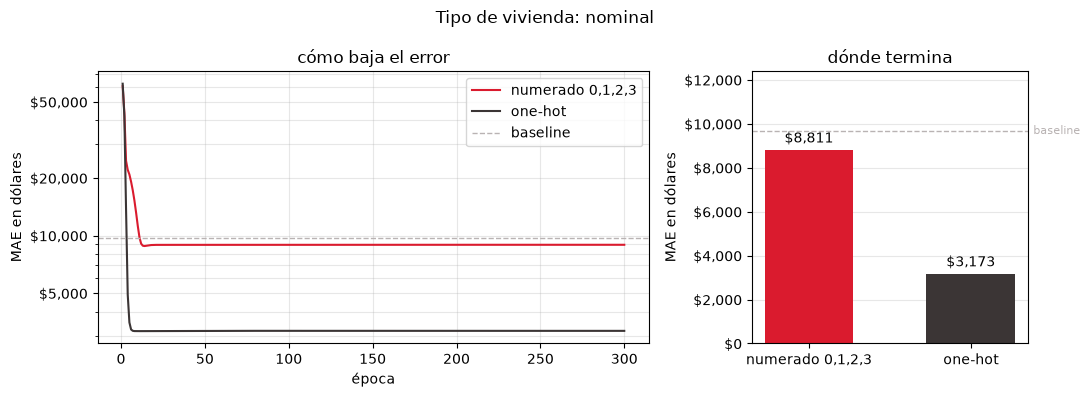

In [20]:
y = datos.precio_solo_tipo.to_numpy() / 1000

X_mal = np.array([TIPOS.index(t) for t in datos.tipo_vivienda], dtype="float32").reshape(-1, 1)
keras.utils.set_random_seed(42)
red_mal = keras.Sequential([
    keras.Input(shape=(1,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_mal.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_mal = red_mal.fit(X_mal, y, epochs=300, batch_size=32, verbose=0)

X_bien = onehot(datos.tipo_vivienda, TIPOS)
keras.utils.set_random_seed(42)
red_bien = keras.Sequential([
    keras.Input(shape=(len(TIPOS),)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_bien.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_bien = red_bien.fit(X_bien, y, epochs=300, batch_size=32, verbose=0)

base = np.abs(y - y.mean()).mean()
mae_mal  = red_mal.evaluate(X_mal, y, verbose=0)[1]
mae_bien = red_bien.evaluate(X_bien, y, verbose=0)[1]
print(f"tipo numerado 0,1,2,3   MAE ${mae_mal*1000:,.0f}   (baseline ${base*1000:,.0f})")
print(f"tipo con one-hot        MAE ${mae_bien*1000:,.0f}   (baseline ${base*1000:,.0f})")
print("\nnumerarlas obliga a la red a inventar un orden entre categorías que no lo tienen")

comparar("Tipo de vivienda: nominal", [
    ("numerado 0,1,2,3",  h_mal,  mae_mal),
    ("one-hot", h_bien, mae_bien),
], base=base)


## 6 · Nominal de cardinalidad alta → embedding · **d floats**

Con 60 barrios, one-hot daría 60 posiciones casi todas en cero, y cada barrio aprendería aislado del resto.

Un **embedding** es una tabla entrenable de `60 × d`: cada barrio es una fila de `d` floats que la red ajusta como cualquier otro peso.

Del lado del dato lo único que se prepara es **el índice entero**. La tabla vive adentro del modelo.

In [21]:
datos = df[["barrio", "precio_solo_barrio"]]
print(datos.head(8).to_string(index=False))
print(f"\n{datos.barrio.nunique()} barrios distintos")

BARRIOS = list(df.barrio.cat.categories)                   # ya vino con la carga
IDX_BARRIO = {b: i + 1 for i, b in enumerate(BARRIOS)}     # el 0 queda para "no visto"
DIM_BARRIO = 8

print("\nvalor             ->  índice")
for v in [BARRIOS[0], BARRIOS[7], BARRIOS[-1], "barrio_zzz"]:
    print(f"  {v:<15} ->  {IDX_BARRIO.get(v, 0)}")
print(f"\nun entero, no un float de entrada. Adentro del modelo busca su fila en una")
print(f"tabla de {len(BARRIOS)+1} x {DIM_BARRIO}  ->  {DIM_BARRIO} floats por casa")

   barrio  precio_solo_barrio
barrio_27             67256.0
barrio_15             42023.0
barrio_45             66539.0
barrio_58             30871.0
barrio_15             40200.0
barrio_46             78774.0
barrio_15             33614.0
barrio_43             64419.0

60 barrios distintos

valor             ->  índice
  barrio_00       ->  1
  barrio_07       ->  8
  barrio_59       ->  60
  barrio_zzz      ->  0

un entero, no un float de entrada. Adentro del modelo busca su fila en una
tabla de 61 x 8  ->  8 floats por casa


In [22]:
y = datos.precio_solo_barrio.to_numpy() / 1000
X = np.array([IDX_BARRIO[b] for b in datos.barrio], dtype="int32").reshape(-1, 1)

keras.utils.set_random_seed(42)
red = keras.Sequential([
    keras.Input(shape=(1,), dtype="int32"),
    layers.Embedding(len(BARRIOS) + 1, DIM_BARRIO),
    layers.Flatten(),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
red.fit(X, y, epochs=300, batch_size=32, verbose=0)

print(f"barrio con embedding   MAE ${red.evaluate(X, y, verbose=0)[1]*1000:,.0f}"
      f"   (baseline ${np.abs(y - y.mean()).mean()*1000:,.0f})")
print(f"\nla tabla tiene {(len(BARRIOS)+1)*DIM_BARRIO} parámetros y le da a cada barrio su propio vector")

barrio con embedding   MAE $3,204   (baseline $15,919)

la tabla tiene 488 parámetros y le da a cada barrio su propio vector


## 7 · Código con forma de número → embedding, nunca como número · **d floats**

El código postal es la trampa más silenciosa: está guardado como entero, así que entra en un `Dense` sin protestar. Pero **la resta entre dos códigos no significa nada**. El 1039 no es "más" que el 1001.

Si entra como número, la red solo puede aprender una relación monótona con el precio, y en los datos esa relación no existe.

In [23]:
datos = df[["codigo_postal", "precio_solo_cp"]]
print(datos.head(8).to_string(index=False))

prom = datos.groupby("codigo_postal", observed=True).precio_solo_cp.mean()
print("\nlos cinco más caros  :", list(prom.nlargest(5).index))
print("los cinco más baratos:", list(prom.nsmallest(5).index))
print("-> mezclados a lo largo de todo el rango: no hay un orden que aprovechar")

CP = list(df.codigo_postal.cat.categories)                 # category, no entero
IDX_CP = {c: i + 1 for i, c in enumerate(CP)}
DIM_CP = 4

print("\nvalor      ->  índice")
for v in [CP[0], CP[17], CP[-1]]:
    print(f"  {v}    ->  {IDX_CP[v]}")

codigo_postal  precio_solo_cp
         1017         59781.0
         1022         59709.0
         1018         64971.0
         1012         49000.0
         1012         50162.0
         1036         51062.0
         1027         62285.0
         1003         58570.0

los cinco más caros  : ['1030', '1008', '1038', '1028', '1018']
los cinco más baratos: ['1000', '1034', '1010', '1024', '1035']
-> mezclados a lo largo de todo el rango: no hay un orden que aprovechar

valor      ->  índice
  1000    ->  1
  1017    ->  18
  1039    ->  40


código postal como número     MAE $8,010   (baseline $7,977)
código postal con embedding   MAE $3,145   (baseline $7,977)

como número la red se queda en el baseline: no hay nada monótono que aprender


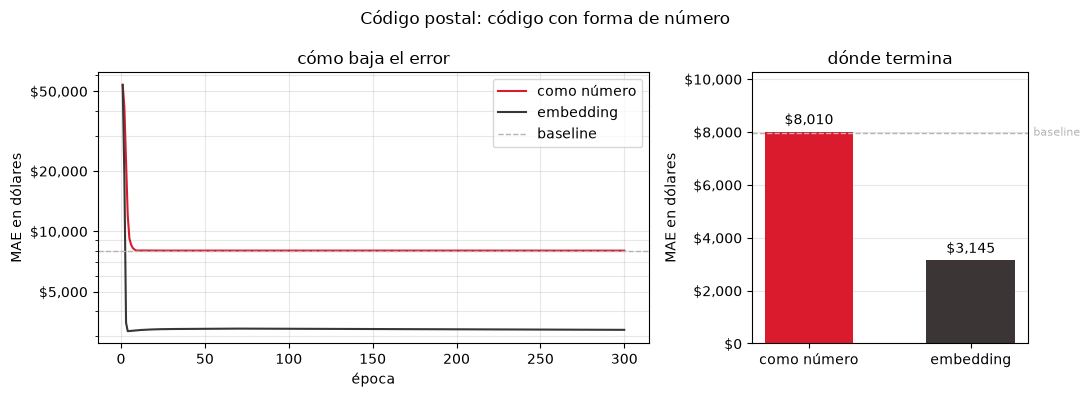

In [24]:
y = datos.precio_solo_cp.to_numpy() / 1000
# Es la unica columna con forma de numero que NO se cargo como numero: para
# tratarla asi hay que forzar el casteo aca, y ese casteo extra ya es la senal.
cp = datos.codigo_postal.astype("float32").to_numpy()

X_mal = ((cp - cp.mean()) / cp.std()).reshape(-1, 1)
keras.utils.set_random_seed(42)
red_mal = keras.Sequential([
    keras.Input(shape=(1,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_mal.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_mal = red_mal.fit(X_mal, y, epochs=300, batch_size=32, verbose=0)

X_bien = np.array([IDX_CP[c] for c in datos.codigo_postal], dtype="int32").reshape(-1, 1)
keras.utils.set_random_seed(42)
red_bien = keras.Sequential([
    keras.Input(shape=(1,), dtype="int32"),
    layers.Embedding(len(CP) + 1, DIM_CP),
    layers.Flatten(),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_bien.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_bien = red_bien.fit(X_bien, y, epochs=300, batch_size=32, verbose=0)

base = np.abs(y - y.mean()).mean()
mae_mal  = red_mal.evaluate(X_mal, y, verbose=0)[1]
mae_bien = red_bien.evaluate(X_bien, y, verbose=0)[1]
print(f"código postal como número     MAE ${mae_mal*1000:,.0f}   (baseline ${base*1000:,.0f})")
print(f"código postal con embedding   MAE ${mae_bien*1000:,.0f}   (baseline ${base*1000:,.0f})")
print("\ncomo número la red se queda en el baseline: no hay nada monótono que aprender")

comparar("Código postal: código con forma de número", [
    ("como número",  h_mal,  mae_mal),
    ("embedding", h_bien, mae_bien),
], base=base)


## 8 · Cíclica → seno y coseno · **2 floats**

El mes va de 1 a 12 y **diciembre está al lado de enero**. Como entero, la red ve 12 y 1 como los dos extremos, que es justo lo contrario.

Dos posiciones lo arreglan: `sin(2πt/12)` y `cos(2πt/12)` ponen los doce meses sobre un círculo.

In [25]:
datos = df[["mes_venta", "precio_solo_mes"]]
print(datos.head(8).to_string(index=False))
print("\nprecio promedio por mes:")
print(datos.groupby("mes_venta", observed=True).precio_solo_mes.mean().round(0).to_string())

def ciclica(v, periodo):
    t = np.asarray(v, dtype="float32")
    return np.stack([np.sin(2*np.pi*t/periodo), np.cos(2*np.pi*t/periodo)], axis=1)

enc = ciclica([1, 6, 11, 12], 12)
print("\nvalor      ->  floats            (seno, coseno)")
for v, f in zip([1, 6, 11, 12], enc):
    print(f"  mes {v:<6} ->  {np.round(f, 2)}")
print(f"\ndistancia diciembre-enero: {np.linalg.norm(enc[3]-enc[0]):.3f}")
print(f"distancia enero-junio    : {np.linalg.norm(enc[1]-enc[0]):.3f}   <- diciembre y enero quedan cerca")

 mes_venta  precio_solo_mes
       7.0          54313.0
       7.0          59926.0
       8.0          53390.0
      10.0          55028.0
       7.0          53295.0
      11.0          44680.0
       4.0          66088.0
      10.0          44948.0

precio promedio por mes:
mes_venta
1.0     64958.0
2.0     68059.0
3.0     69219.0
4.0     67832.0
5.0     64712.0
6.0     60315.0
7.0     55656.0
8.0     52809.0
9.0     51086.0
10.0    51765.0
11.0    55134.0
12.0    59767.0

valor      ->  floats            (seno, coseno)
  mes 1      ->  [0.5  0.87]
  mes 6      ->  [-0. -1.]
  mes 11     ->  [-0.5   0.87]
  mes 12     ->  [0. 1.]

distancia diciembre-enero: 0.518
distancia enero-junio    : 1.932   <- diciembre y enero quedan cerca


mes como entero 1..12    MAE $3,772   (baseline $6,446)
mes como seno y coseno   MAE $3,167   (baseline $6,446)

con dos floats la red recupera la estacionalidad; con uno no puede cerrar el círculo


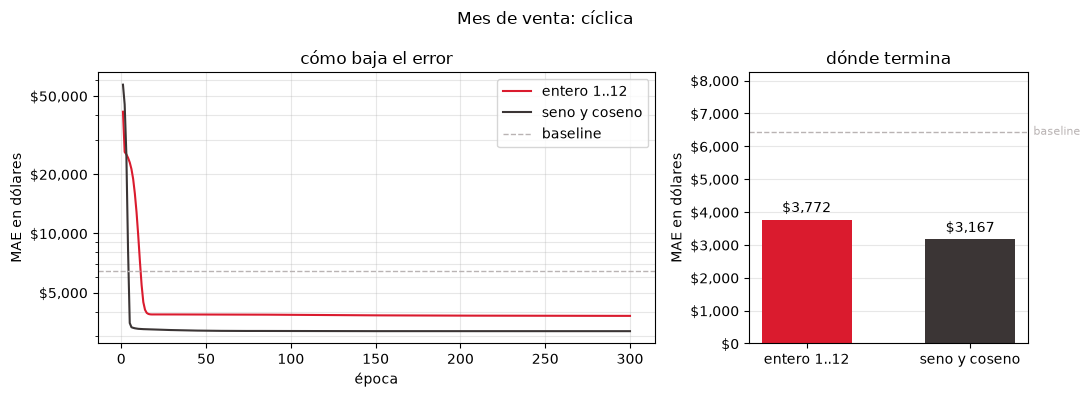

In [26]:
y = datos.precio_solo_mes.to_numpy() / 1000
mes = datos.mes_venta.to_numpy()

X_mal = mes.reshape(-1, 1)
keras.utils.set_random_seed(42)
red_mal = keras.Sequential([
    keras.Input(shape=(1,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_mal.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_mal = red_mal.fit(X_mal, y, epochs=300, batch_size=32, verbose=0)

X_bien = ciclica(mes, 12)
keras.utils.set_random_seed(42)
red_bien = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_bien.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_bien = red_bien.fit(X_bien, y, epochs=300, batch_size=32, verbose=0)

base = np.abs(y - y.mean()).mean()
mae_mal  = red_mal.evaluate(X_mal, y, verbose=0)[1]
mae_bien = red_bien.evaluate(X_bien, y, verbose=0)[1]
print(f"mes como entero 1..12    MAE ${mae_mal*1000:,.0f}   (baseline ${base*1000:,.0f})")
print(f"mes como seno y coseno   MAE ${mae_bien*1000:,.0f}   (baseline ${base*1000:,.0f})")
print("\ncon dos floats la red recupera la estacionalidad; con uno no puede cerrar el círculo")

comparar("Mes de venta: cíclica", [
    ("entero 1..12",  h_mal,  mae_mal),
    ("seno y coseno", h_bien, mae_bien),
], base=base)


## 9 · Fecha → hace cuánto · **1 float**

El año de alta (1998, 2015) tiene una magnitud enorme y sin sentido para la red. Lo que importa es **hace cuánto**, que sí es una cantidad.

In [27]:
HOY = 2024
datos = df[["anio_alta", "precio_solo_antiguedad"]]
print(datos.head(8).to_string(index=False))

anio = datos.anio_alta.to_numpy()
ant = HOY - anio
y = datos.precio_solo_antiguedad.to_numpy() / 1000

mu_a, sd_a = ant.mean(), ant.std()
print("\nvalor      ->  antigüedad  ->  float")
for v in [1950, 1985, 2005, 2020]:
    print(f"  {v}     ->  {HOY-v:>3} años   ->  [{((HOY-v)-mu_a)/sd_a:+.2f}]")

 anio_alta  precio_solo_antiguedad
    1981.0                 44923.0
    1950.0                 35658.0
    1971.0                 41491.0
    1979.0                 48004.0
    2019.0                 58611.0
    2008.0                 56125.0
    1960.0                 41547.0
    1950.0                 38519.0

valor      ->  antigüedad  ->  float
  1950     ->   74 años   ->  [+1.72]
  1985     ->   39 años   ->  [+0.01]
  2005     ->   19 años   ->  [-0.97]
  2020     ->    4 años   ->  [-1.71]


año crudo                MAE $5,666   (baseline $6,034)
antigüedad con z-score   MAE $3,135   (baseline $6,034)


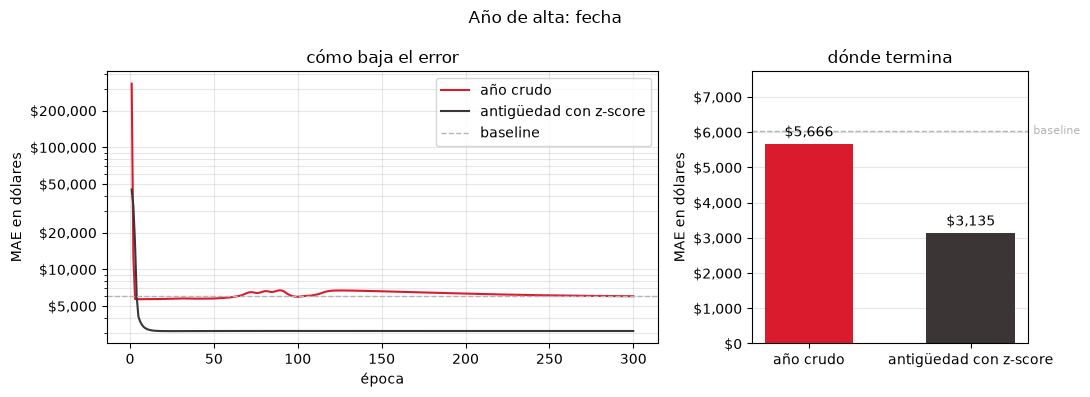

In [28]:
X_mal = anio.reshape(-1, 1)
keras.utils.set_random_seed(42)
red_mal = keras.Sequential([
    keras.Input(shape=(1,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_mal.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_mal = red_mal.fit(X_mal, y, epochs=300, batch_size=32, verbose=0)

X_bien = ((ant - mu_a) / sd_a).reshape(-1, 1)
keras.utils.set_random_seed(42)
red_bien = keras.Sequential([
    keras.Input(shape=(1,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1),
])
red_bien.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
h_bien = red_bien.fit(X_bien, y, epochs=300, batch_size=32, verbose=0)

base = np.abs(y - y.mean()).mean()
mae_mal  = red_mal.evaluate(X_mal, y, verbose=0)[1]
mae_bien = red_bien.evaluate(X_bien, y, verbose=0)[1]
print(f"año crudo                MAE ${mae_mal*1000:,.0f}   (baseline ${base*1000:,.0f})")
print(f"antigüedad con z-score   MAE ${mae_bien*1000:,.0f}   (baseline ${base*1000:,.0f})")

comparar("Año de alta: fecha", [
    ("año crudo",  h_mal,  mae_mal),
    ("antigüedad con z-score", h_bien, mae_bien),
], base=base)


## 10 · Identificador único → se descarta · **0 floats**

El id de la publicación no tiene ninguna relación con el precio. Hay dos formas de dejarlo entrar, y las dos terminan mal por motivos distintos.

**Como número** no aporta nada: la red se queda en el baseline. Es inútil, pero inofensivo.

**Como categoría** es la trampa peligrosa. Un id tiene cardinalidad altísima, así que parece pedir un embedding —y un embedding le da a cada id su propio vector de parámetros libres. Con eso la red **memoriza** el precio de cada fila de train.

Es el único caso del notebook donde el error no se ve en el entrenamiento, así que es el único que separa train de test.

In [29]:
datos = df[["listing_id", "precio_solo_id"]].head(400)     # 400 alcanzan para verlo
print(datos.head(8).to_string(index=False))
print(f"\ncorrelación entre el id y el precio: {np.corrcoef(datos.listing_id, datos.precio_solo_id)[0,1]:+.4f}")

# El id se cargo como int64 a proposito: es un identificador, no una cantidad.
# Pasarlo a float es exactamente lo que esta seccion viene a desaconsejar.
ids = datos.listing_id.to_numpy(dtype="float32")
y = datos.precio_solo_id.to_numpy() / 1000
corte = int(len(datos) * 0.7)
base = np.abs(y[corte:] - y[:corte].mean()).mean()

 listing_id  precio_solo_id
     271195         58585.0
     916831         61628.0
     951972         59109.0
     199237         63294.0
     538038         60242.0
     911684         56253.0
     434757         61182.0
     193715         61998.0

correlación entre el id y el precio: +0.0345


In [30]:
X_num = ((ids - ids[:corte].mean()) / ids[:corte].std()).reshape(-1, 1)

keras.utils.set_random_seed(42)
red_num = keras.Sequential([
    keras.Input(shape=(1,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1),
])
red_num.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
red_num.fit(X_num[:corte], y[:corte], epochs=400, batch_size=16, verbose=0)

print(f"id como número   train MAE ${red_num.evaluate(X_num[:corte], y[:corte], verbose=0)[1]*1000:,.0f}")
print(f"id como número   test  MAE ${red_num.evaluate(X_num[corte:], y[corte:], verbose=0)[1]*1000:,.0f}   (baseline ${base*1000:,.0f})")
print("\nni en train baja: como número el id no aporta absolutamente nada")

id como número   train MAE $3,434
id como número   test  MAE $3,772   (baseline $3,762)

ni en train baja: como número el id no aporta absolutamente nada


In [31]:
# Como categoria, con embedding: un vector propio por id.
X_cat = np.arange(1, len(datos) + 1).reshape(-1, 1).astype("int32")

keras.utils.set_random_seed(42)
red_cat = keras.Sequential([
    keras.Input(shape=(1,), dtype="int32"),
    layers.Embedding(len(datos) + 1, 8),
    layers.Flatten(),
    layers.Dense(16, activation="relu"),
    layers.Dense(1),
])
red_cat.compile(optimizer=keras.optimizers.Adam(0.01), loss="mse", metrics=["mae"])
red_cat.fit(X_cat[:corte], y[:corte], epochs=400, batch_size=16, verbose=0)

print(f"id con embedding   train MAE ${red_cat.evaluate(X_cat[:corte], y[:corte], verbose=0)[1]*1000:,.0f}")
print(f"id con embedding   test  MAE ${red_cat.evaluate(X_cat[corte:], y[corte:], verbose=0)[1]*1000:,.0f}   (baseline ${base*1000:,.0f})")
print("\nen train el error es prácticamente cero y en test se dispara.")
print("Eso es memorización pura, y es todo lo que un identificador puede aportar.")
print("La conversión correcta es no convertirlo: se descarta.")

id con embedding   train MAE $0
id con embedding   test  MAE $36,594   (baseline $3,762)

en train el error es prácticamente cero y en test se dispara.
Eso es memorización pura, y es todo lo que un identificador puede aportar.
La conversión correcta es no convertirlo: se descarta.


## 11 · Todo junto

Hasta acá cada variable vivió sola, con su precio aislado. Ahora va **`precio`**, el completo: todas aportan a la vez, más ruido de 18.000.

Ese ruido es el **piso**: ningún modelo puede bajar de ahí.

### La tabla de decisiones, completada

| Columna | Qué es | Codificación | # de inputs (floats) |
|---|---|---|---|
| `listing_id` | Identificador único | Se descarta | **0** |
| `tiene_cochera` | Booleana | 0 o 1, tal cual | 1 |
| `m2` | Numérica con magnitud | z-score | 1 |
| `banos` | Numérica con magnitud | z-score | 1 |
| `ingreso_zona` | Numérica con cola larga | `log(1+x)` y después z-score | 1 |
| `estado` | Ordinal | Float de orden **más** one-hot | 1 + 4 |
| `tipo_vivienda` | Nominal, cardinalidad baja (4) | One-hot | 4 |
| `barrio` | Nominal, cardinalidad alta (60) | Embedding de dimensión 8 | 8 |
| `codigo_postal` | Código con forma de número (40) | Embedding de dimensión 4 | 4 |
| `mes_venta` | Cíclica | Seno y coseno | 2 |
| `anio_alta` | Fecha | Antigüedad con z-score | 1 |

**Total: 28 floats.** Ese número tiene que ser el ancho de la capa de entrada.

### Partir antes de tocar nada

Las medias, los desvíos y los diccionarios de categorías **salen solo del train**. Por eso el split va primero.

In [32]:
from sklearn.model_selection import train_test_split

i_tr, i_tmp = train_test_split(np.arange(len(df)), test_size=0.30, random_state=42)
i_va, i_te  = train_test_split(i_tmp, test_size=1/3, random_state=42)
tr, va, te = df.iloc[i_tr], df.iloc[i_va], df.iloc[i_te]
print(f"train {len(tr)} | validación {len(va)} | test {len(te)}")

MU_M2,  SD_M2  = tr.m2.mean(), tr.m2.std()
MU_BAN, SD_BAN = tr.banos.mean(), tr.banos.std()
_l = np.log1p(tr.ingreso_zona.to_numpy())
MU_ING, SD_ING = _l.mean(), _l.std()
_a = (HOY - tr.anio_alta).to_numpy()
MU_ANT, SD_ANT = _a.mean(), _a.std()

# Declarar el tipo al cargar dice QUE es cada columna. Los diccionarios que el
# modelo usa son otra cosa: son parametros, y salen solo del train.
CAT_TIPO   = sorted(tr.tipo_vivienda.astype(str).unique())
IDX_BARRIO = {b: i + 1 for i, b in enumerate(sorted(tr.barrio.astype(str).unique()))}
IDX_CP     = {c: i + 1 for i, c in enumerate(sorted(tr.codigo_postal.astype(str).unique()))}
print(f"diccionarios del train: {len(CAT_TIPO)} tipos, {len(IDX_BARRIO)} barrios, {len(IDX_CP)} códigos")

train 1400 | validación 400 | test 200
diccionarios del train: 4 tipos, 60 barrios, 40 códigos


In [33]:
def preparar(d):
    floats = np.hstack([
        d.tiene_cochera.to_numpy().reshape(-1, 1),                                 # 1
        ((d.m2.to_numpy() - MU_M2) / SD_M2).reshape(-1, 1),                        # 1
        ((d.banos.to_numpy() - MU_BAN) / SD_BAN).reshape(-1, 1),                   # 1
        ((np.log1p(d.ingreso_zona.to_numpy()) - MU_ING) / SD_ING).reshape(-1, 1),  # 1
        ordinal(d.estado),                                                         # 1 + 4
        onehot(d.tipo_vivienda.astype(str), CAT_TIPO),                             # 4
        ciclica(d.mes_venta.to_numpy(), 12),                                       # 2
        (((HOY - d.anio_alta.to_numpy()) - MU_ANT) / SD_ANT).reshape(-1, 1),       # 1
    ]).astype("float32")
    return {
        "floats": floats,
        "barrio": np.array([IDX_BARRIO.get(b, 0) for b in d.barrio.astype(str)], dtype="int32").reshape(-1, 1),
        "cp":     np.array([IDX_CP.get(c, 0) for c in d.codigo_postal.astype(str)], dtype="int32").reshape(-1, 1),
    }

Xtr, Xva, Xte = preparar(tr), preparar(va), preparar(te)
ytr = tr.precio.to_numpy() / 1000
yva = va.precio.to_numpy() / 1000
yte = te.precio.to_numpy() / 1000

N_FLOATS = Xtr["floats"].shape[1]
TOTAL = N_FLOATS + DIM_BARRIO + DIM_CP
print(f"bloque denso     : {N_FLOATS}")
print(f"embedding barrio : {DIM_BARRIO}")
print(f"embedding cp     : {DIM_CP}")
print(f"-----------------------")
print(f"entrada a la red : {TOTAL} floats   (la tabla decía 28 -> {'coincide' if TOTAL == 28 else 'NO coincide'})")

bloque denso     : 16
embedding barrio : 8
embedding cp     : 4
-----------------------
entrada a la red : 28 floats   (la tabla decía 28 -> coincide)


### La red

Chica a propósito: lo que importa acá es la entrada, no la arquitectura. La última capa es **una neurona sin activación**, porque predecir un precio es regresión.

In [34]:
keras.utils.set_random_seed(42)

in_floats = keras.Input(shape=(N_FLOATS,), name="floats")
in_barrio = keras.Input(shape=(1,), dtype="int32", name="barrio")
in_cp     = keras.Input(shape=(1,), dtype="int32", name="cp")

e_barrio = layers.Flatten()(layers.Embedding(len(IDX_BARRIO) + 1, DIM_BARRIO)(in_barrio))
e_cp     = layers.Flatten()(layers.Embedding(len(IDX_CP) + 1, DIM_CP)(in_cp))

x = layers.Concatenate()([in_floats, e_barrio, e_cp])
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(16, activation="relu")(x)
out = layers.Dense(1)(x)

model = keras.Model([in_floats, in_barrio, in_cp], out)
model.compile(optimizer=keras.optimizers.Adam(0.01), loss="huber", metrics=["mae"])
model.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ barrio (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cp (InputLayer)     │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 8)      │        488 │ barrio[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 4)      │        164 │ cp[0][0]          │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ floats (InputLayer) │ (None, 16)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 8)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 4)         │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28)        │          0 │ floats[0][0],     │
│ (Concatenate)       │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 32)        │        928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 16)        │        528 │ dense_45[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 1)         │         17 │ dense_46[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,125 (8.30 KB)

 Trainable params: 2,125 (8.30 KB)

 Non-trainable params: 0 (0.00 B)

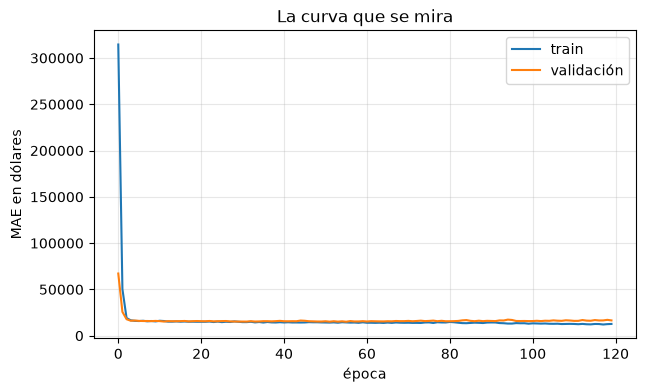

In [35]:
hist = model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=120, batch_size=32, verbose=0)

plt.figure(figsize=(7, 4))
plt.plot(np.array(hist.history["mae"]) * 1000, label="train")
plt.plot(np.array(hist.history["val_mae"]) * 1000, label="validación")
plt.xlabel("época"); plt.ylabel("MAE en dólares")
plt.title("La curva que se mira"); plt.legend(); plt.grid(alpha=.3)
plt.show()

In [36]:
mae = model.evaluate(Xte, yte, verbose=0)[1]
piso = np.sqrt(2/np.pi) * 18_000        # el ruido del precio completo
print(f"MAE en test: ${mae*1000:,.0f}")
print(f"precio promedio: ${te.precio.mean():,.0f}  ->  {100*mae*1000/te.precio.mean():.1f}% del precio típico")
print(f"\npiso del dataset (solo el ruido): ${piso:,.0f}")
print(f"la red quedó a ${mae*1000 - piso:,.0f} del piso -> recuperó casi toda la fórmula")

MAE en test: $16,435
precio promedio: $383,527  ->  4.3% del precio típico

piso del dataset (solo el ruido): $14,362
la red quedó a $2,073 del piso -> recuperó casi toda la fórmula


### Y si se codifica todo mal

Misma red, mismas épocas, mismos datos. Cambia solo la entrada: se cometen a la vez las trampas que fuimos viendo una por una.

Para que la comparación sea justa, **todas las columnas van igual de normalizadas**. Lo único que cambia es la *semántica*: el mes entra como entero, el código postal como magnitud, el id como número, las categorías numeradas, el ordinal sin one-hot y el ingreso sin log.

In [37]:
CRUDAS = ["m2", "banos", "ingreso_zona", "mes_venta", "anio_alta", "listing_id"]
MU_MAL = {c: tr[c].mean() for c in CRUDAS}
SD_MAL = {c: tr[c].std() for c in CRUDAS}
MU_CP, SD_CP = tr.codigo_postal.astype("float32").mean(), tr.codigo_postal.astype("float32").std()

def preparar_mal(d):
    z = lambda c: ((d[c].to_numpy() - MU_MAL[c]) / SD_MAL[c]).reshape(-1, 1)
    zcp = ((d.codigo_postal.astype("float32").to_numpy() - MU_CP) / SD_CP).reshape(-1, 1)
    orden_tipo = np.array([CAT_TIPO.index(t) for t in d.tipo_vivienda.astype(str)], dtype="float32")
    idx_b = np.array([IDX_BARRIO.get(b, 0) for b in d.barrio.astype(str)], dtype="float32")
    return np.hstack([
        d.tiene_cochera.to_numpy().reshape(-1, 1),                          # está bien
        z("m2"), z("banos"),                                                # está bien
        z("ingreso_zona"),                                                  # mal: sin log
        (d.estado.cat.codes.to_numpy(dtype="float32") / 3).reshape(-1, 1),  # mal: solo el orden
        (orden_tipo / 3).reshape(-1, 1),                                    # mal: categorías numeradas
        z("mes_venta"),                                                     # mal: cíclica como entero
        z("anio_alta"),                                                     # mal: fecha como magnitud
        zcp,                                                                # mal: código como número
        z("listing_id"),                                                    # mal: identificador único
        (idx_b / len(IDX_BARRIO)).reshape(-1, 1),                           # mal: índice como número
    ]).astype("float32")

Mtr, Mva, Mte = preparar_mal(tr), preparar_mal(va), preparar_mal(te)

keras.utils.set_random_seed(42)
malo = keras.Sequential([
    keras.Input(shape=(Mtr.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1),
])
malo.compile(optimizer=keras.optimizers.Adam(0.01), loss="huber", metrics=["mae"])
h_malo = malo.fit(Mtr, ytr, validation_data=(Mva, yva), epochs=120, batch_size=32, verbose=0)

mae_malo = malo.evaluate(Mte, yte, verbose=0)[1]
print(f"entrada mal codificada: {Mtr.shape[1]} floats\n")
print(f"MAE en test  bien codificado: ${mae*1000:,.0f}")
print(f"MAE en test  mal  codificado: ${mae_malo*1000:,.0f}")
print(f"diferencia: {100*(mae_malo-mae)/mae:+.0f}%")

entrada mal codificada: 11 floats

MAE en test  bien codificado: $16,435
MAE en test  mal  codificado: $24,650
diferencia: +50%


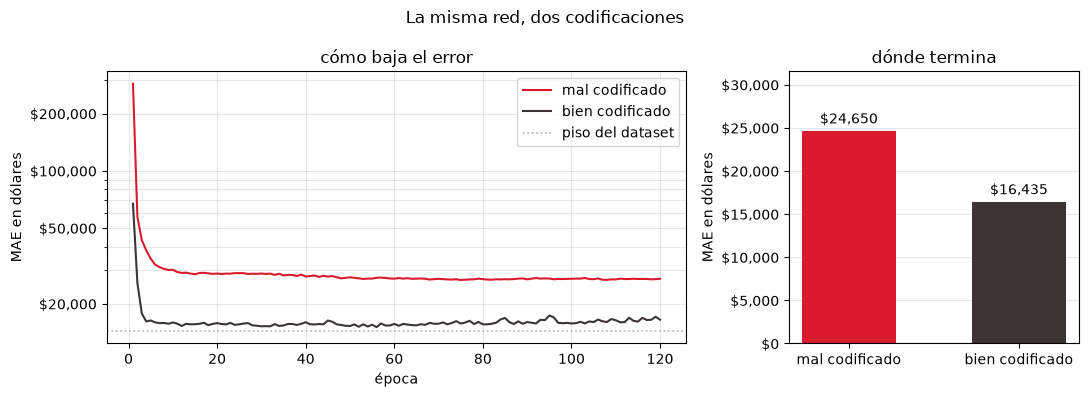

In [38]:
comparar("La misma red, dos codificaciones", [
    ("mal codificado",  h_malo, mae_malo),
    ("bien codificado", hist,   mae),
], clave="val_mae", piso=piso)


## Para llevarse

1. **El ancho de la capa de entrada no se elige: se cuenta.** Sale de sumar los floats que produce cada columna, y esa suma es la tabla de decisiones.
2. **La codificación incorrecta también entrena.** Ninguno de los experimentos de arriba tiró un error: los malos simplemente dieron un modelo peor.
3. **El identificador único es el único que no se ve en train.** Los demás errores se notan en la loss; la memorización de un id solo aparece cuando se mira validación.
4. **Todo lo que se aprende sale del train**: medias, desvíos y diccionarios de categorías.
5. **El modelo entrenado no son solo los pesos.** Son los pesos más las μ y σ más los diccionarios. Si se guardan solo los pesos, el modelo queda inservible.